# How did the Government of India and RBI respond?

Lists what the Government of India and RBI did after the 2014-15, 2023 and 2026 weak monsoons, and checks what prices did before and after each step.

Data: a timeline I built from official notices (PIB, DGFT, RBI, Cabinet), with a source link for each row, and the monthly CPI from rain_and_food_prices.ipynb. The 2009 drought is left out because monthly CPI starts in 2012.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = "data/raw/"
CLEAN = "data/clean/"

measures = pd.read_csv(RAW + "drought_policy_measures.csv", parse_dates=["date"])
monthly = pd.read_csv(CLEAN + "cpi_monthly_2012_2025.csv", parse_dates=["date"]).set_index("date")
measures[["date", "episode", "authority", "measure", "target"]]

,date,episode,authority,measure,target
0,2015-01-15,2014-15 drought,RBI,Repo rate cut from 8.00% to 7.75%,headline
1,2015-06-02,2014-15 drought,RBI,Repo rate cut from 7.50% to 7.25%,headline
2,2015-09-16,2014-15 drought,Union Cabinet,Extra 50 days of MGNREGA work in drought or ca...,rural income
3,2015-09-29,2014-15 drought,RBI,Repo rate cut from 7.25% to 6.75%,headline
4,2015-12-01,2014-15 drought,Government of India,Pulses buffer stock set up (NAFED and SFAC to ...,pulses
5,2023-06-12,2023 deficient monsoon,Government of India (DFPD),Stock limits on wheat for traders and processo...,cereals
6,2023-06-28,2023 deficient monsoon,FCI,First weekly e-auction of FCI wheat and rice t...,cereals
7,2023-07-20,2023 deficient monsoon,DGFT,Export of non-basmati white rice prohibited (N...,cereals
8,2023-08-19,2023 deficient monsoon,Government of India,40% export duty on onions till 31 December 2023,vegetables
9,2023-11-06,2023 deficient monsoon,Government of India,Bharat Atta sold at Rs 27.50 per kg through NA...,cereals


## Before and after each measure

For each measure aimed at a food group, I compare that group's average inflation in the 6 months before the measure with the 6 months after. I do the same for overall food inflation (CFPI) as a rough benchmark. If the target group cools a lot more than food overall, that fits the measure helping, but it doesn't prove it.

In [2]:
def window_average(series, month, start, end):
    months = [month + pd.DateOffset(months=k) for k in range(start, end + 1)]
    return series.reindex(months).mean()

rows = []
for _, m in measures[measures["target"].isin(["cereals", "pulses", "vegetables"])].iterrows():
    month = m["date"].to_period("M").to_timestamp()
    target, food = monthly[m["target"]], monthly["food"]
    rows.append({
        "date": m["date"].date(),
        "measure": m["measure"][:60],
        "target": m["target"],
        "target before": window_average(target, month, -6, -1),
        "target after": window_average(target, month, 1, 6),
        "food before": window_average(food, month, -6, -1),
        "food after": window_average(food, month, 1, 6),
    })
before_after = pd.DataFrame(rows)
before_after["target change"] = before_after["target after"] - before_after["target before"]
before_after["food change"] = before_after["food after"] - before_after["food before"]
before_after["gap"] = before_after["target change"] - before_after["food change"]
before_after.round(1)

,date,measure,target,target before,target after,food before,food after,target change,food change,gap
0,2015-12-01,Pulses buffer stock set up (NAFED and SFAC to ...,pulses,31.5,34.8,4.2,6.5,3.3,2.3,0.9
1,2023-06-12,Stock limits on wheat for traders and processo...,cereals,14.7,11.1,4.6,8.8,-3.6,4.2,-7.8
2,2023-06-28,First weekly e-auction of FCI wheat and rice t...,cereals,14.7,11.1,4.6,8.8,-3.6,4.2,-7.8
3,2023-07-20,Export of non-basmati white rice prohibited (N...,cereals,14.6,10.3,4.7,8.3,-4.3,3.6,-7.9
4,2023-08-19,40% export duty on onions till 31 December 2023,vegetables,0.4,18.2,5.6,8.1,17.8,2.5,15.3
5,2023-11-06,Bharat Atta sold at Rs 27.50 per kg through NA...,cereals,12.0,8.5,7.0,8.7,-3.5,1.7,-5.2
6,2024-09-28,Ban on non-basmati white rice exports lifted w...,cereals,8.3,6.4,7.7,6.8,-1.9,-0.9,-0.9


## The episodes month by month

Inflation for the targeted food groups, with a dashed line at each measure.

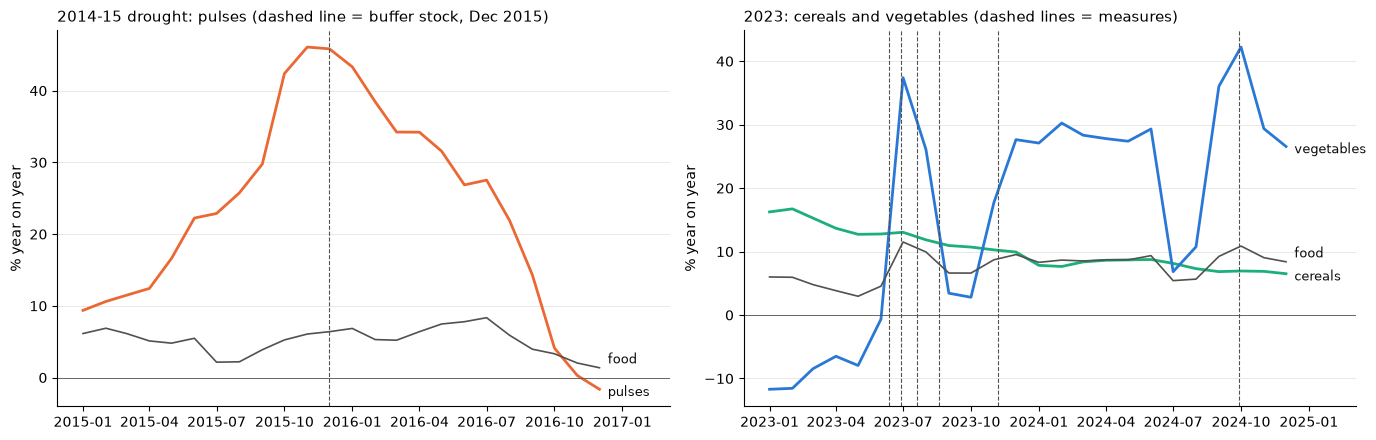

In [3]:
def episode_chart(ax, start, end, columns, episode):
    part = monthly.loc[start:end]
    colors = {"pulses": "#eb6834", "cereals": "#1baf7a", "vegetables": "#2a78d6", "food": "#52514e"}
    for col in columns:
        ax.plot(part.index, part[col], color=colors[col], linewidth=2 if col != "food" else 1.2)
        ax.annotate(col, (part.index[-1], part[col].iloc[-1]), xytext=(6, 6 if col == "food" else -2),
                    textcoords="offset points", va="center", fontsize=9, color="#0b0b0b")
    for _, m in measures[measures["episode"] == episode].iterrows():
        if m["target"] in columns and start <= str(m["date"].date()) <= end:
            ax.axvline(m["date"], color="#52514e", linewidth=0.8, linestyle="--")
    ax.axhline(0, color="#52514e", linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_ylabel("% year on year")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
episode_chart(axes[0], "2015-01", "2016-12", ["pulses", "food"], "2014-15 drought")
axes[0].set_title("2014-15 drought: pulses (dashed line = buffer stock, Dec 2015)", loc="left", fontsize=11)
episode_chart(axes[1], "2023-01", "2024-12", ["cereals", "vegetables", "food"], "2023 deficient monsoon")
axes[1].set_title("2023: cereals and vegetables (dashed lines = measures)", loc="left", fontsize=11)
for ax in axes:
    ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] + 60)
plt.tight_layout()
plt.show()

## What this shows, and what it can't

Pulses inflation peaked at 46% in November 2015, right before the buffer stock was set up. It stayed above 30% for most of the next six months and only fell to about zero a year later, once the next crop came in. In 2023, cereal inflation was already falling before the measures started, but it kept falling while overall food inflation went up, so cereals cooled about 8 points relative to food. Vegetables jumped after the onion export duty, so that measure didn't stop the rise.

These comparisons can't prove the measures worked. The Government of India acts when prices are high, and high prices tend to fall back anyway once the next harvest comes in, so a before and after drop would happen even without the measure. The next harvest, imports and global prices all move at the same time.

## 2026

RBI held the repo rate at 5.25% on 5 August 2026, then raised it by 25 basis points to 5.50% on 7 October and moved its stance from neutral to calibrated tightening. The October statement names the deficient monsoon and El Niño as risks to farm output and rural demand, and says food price rises have spread more widely, with spikes in sugar and onion. Food inflation under the new CPI rose from 2.1% in January to 5.7% in August (see rain_and_food_prices.ipynb). September CPI comes out around 12 October, so this section gets updated after that.

In [4]:
before_after.round(2).to_csv(CLEAN + "policy_before_after.csv", index=False)